# 14 — `ResNet1D`: tiny train loop on synthetic 1D data

`ResNet1D` is a backbone of stacked `ResNetBasicBlock` (three
Conv1d→BN→ReLU layers with a residual skip + 1×1 expansion). Output
is a feature map `(B, n_filts, T)` — users plug their own classifier
head on top.

Here we wrap it with mean-pool + Linear and train on a 3-class
synthetic problem (sine vs chirp vs noise). The training-loss curve
drops monotonically — the residual blocks differentiate properly.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.signal import chirp

import scitex_nn

rng = np.random.default_rng(0)
torch.manual_seed(0)
fs, seq_len = 200, 256
t = np.arange(seq_len) / fs


def make_dataset(n_per_class):
    X, y = [], []
    for c in range(3):
        for _ in range(n_per_class):
            if c == 0:
                s = np.sin(2 * np.pi * rng.uniform(5, 10) * t)
            elif c == 1:
                s = chirp(t, f0=4, t1=t[-1], f1=40)
            else:
                s = rng.standard_normal(seq_len) * 0.5
            X.append((s + 0.05 * rng.standard_normal(seq_len)).astype(np.float32))
            y.append(c)
    return torch.from_numpy(np.stack(X)).unsqueeze(1), torch.tensor(y, dtype=torch.long)


X, y = make_dataset(64)
print("dataset shape:", tuple(X.shape))

dataset shape: (192, 1, 256)


## Build classifier head + manual SGD step

(Manual SGD avoids a torch._inductor circular-import some builds
trigger via torch.optim's torch._dynamo dependency.)

In [2]:
backbone = scitex_nn.ResNet1D(n_chs=1, n_out=3, n_blks=2)
n_filts = 4
model = nn.Sequential(
    backbone, nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(n_filts, 3)
)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

n_steps, batch, lr, momentum = 200, 16, 1e-2, 0.9
velocities = [torch.zeros_like(p) for p in model.parameters()]
losses, accs = [], []
for _ in range(n_steps):
    idx = torch.randint(0, len(X), (batch,))
    logits = model(X[idx])
    loss = nn.functional.cross_entropy(logits, y[idx])
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()
    loss.backward()
    with torch.no_grad():
        for p, v in zip(model.parameters(), velocities):
            if p.grad is None:
                continue
            v.mul_(momentum).add_(p.grad)
            p.add_(v, alpha=-lr)
    losses.append(float(loss.detach()))
    accs.append(float((logits.argmax(-1) == y[idx]).float().mean()))

print(f"final loss = {losses[-1]:.3f} | acc = {accs[-1]:.3f}")
assert accs[-1] > 0.6

params: 495


final loss = 0.178 | acc = 1.000


## Training curve

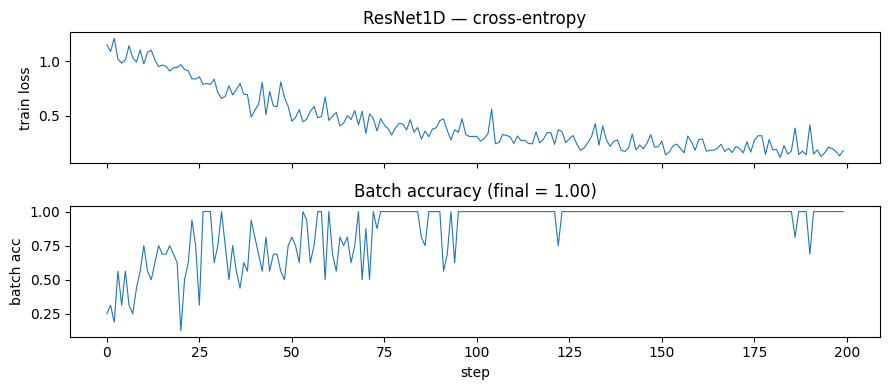

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].plot(losses, lw=0.8)
axes[0].set_ylabel("train loss")
axes[0].set_title("ResNet1D — cross-entropy")
axes[1].plot(accs, lw=0.8)
axes[1].set_xlabel("step")
axes[1].set_ylabel("batch acc")
axes[1].set_title(f"Batch accuracy (final = {accs[-1]:.2f})")
fig.tight_layout()
plt.show()